In [4]:
from matplotlib import pyplot as plt
import sys
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import dask
from tqdm.autonotebook import tqdm  # Fancy progress bars for our loops!
import intake
import fsspec
import math
import warnings
from dask_gateway import Gateway
from dask.distributed import Client
from cartopy import util as cutil

%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6



This code sets up the entire programming environment by importing the specific tools (libraries) needed to handle big climate data on a supercomputer. It loads packages for organizing massive cloud databases (intake, fsspec), performing heavy data analysis (xarray, numpy, pandas), and creating high-quality geographic maps (matplotlib, cartopy). Crucially, it initializes Dask (dask_gateway, Client), which connects this notebook to a distributed cluster of computers so it can process terabytes of data in parallel without crashing your system. 

In [5]:
platform = sys.platform

if (platform == 'win32'):
    import multiprocessing.popen_spawn_win32
else:
    import multiprocessing.popen_spawn_posix

In [6]:
#print(platform)

In [7]:
client = Client()
#client

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35053 instead
  warnings.warn(


This checks whether the computer is running Windows or a Unix-based system (like Mac or Linux) and automatically imports the correct background worker system for that specific platform. Once it sets up those correct platform settings, it launches a master Client program so it can start running your heavy climate data computations in parallel without crashing.

In [72]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


In [73]:
unique_expts = df["source_id"].unique()
#print(unique_expts)

In [74]:
#df['activity_id'].unique

In [75]:
#df['member_id'].unique

In [8]:
#df['institution_id'].unique

In [9]:
#unique_expts = df["experiment_id"].unique()
#print(unique_expts)

In [10]:
#df['variable_id'].unique()

In [11]:
#df['table_id'].unique()

In [ ]:
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
col

This code downloads a master spreadsheet of massive global climate model datasets stored in Google Cloud and loads it into Python. It then creates a smart, searchable "digital library catalog" (col) from that spreadsheet. Instead of making you manually search through millions of files, this catalog allows you to instantly find, filter, and load specific climate data (like temperature or aerosol levels) using simple search keywords.

In [25]:
query = dict(
    experiment_id=['historical'], 
    #table_id='AERmon',                         
    variable_id=['od550so4', 'mmrpm2p5', 'emidust', 'mmrsoa', 'mmrbc', 'mmrss', 'mmrdust', 'mmroa', 'dryso4', 'wetso4'],  
    member_id = 'r1i1p1f1',                     
)


In [26]:
col_subset = col.search(require_all_on=["source_id"], **query)
col_subset.df.groupby("source_id")[["experiment_id", "variable_id"]].nunique()

,experiment_id,variable_id
source_id,,
GFDL-ESM4,1,10


In [23]:
#col_subset

This code acts filters for the massive digital archive of climate data. it defines a query specifying what is needed like historical data, for a specific simulation run (r1i1p1f1), covering 10 exact types of pollution and dust particles like sulfate, black carbon, and sea salt. Next, it searches the archive and applies a strict rule: only keep a climate model if it has all 10 of those requested variables. Finally, it creates a neat summary checklist showing you a list of the successful climate models and counting exactly how many experiments and variables each one has available, allowing only models that have the complete dataset needed before you download starts.

In [24]:
#col_subset.df.head()

In [17]:
#%time ds=col_subset.df

In [44]:
ds =xr.open_mfdataset(col_subset.df.zstore, engine = "zarr")
ds= ds.drop_vars(["ap","b"])
ds= ds.isel(lev=0)
#ds=ds.mean(dim="time")

This code goes out to the internet, opens up all the cloud-hosted climate files in the search, and glues them together into one big dataset. It then sweeps away some extra, unnecessary background variables (ap and b) to keep the data clean and prevent errors. it slices the data to look only at the very first vertical layer of the atmosphere (lev=0), which is the air right above the Earth's surface where we live.

In [45]:
#ds

In [46]:
# Figure titles
titles = {
    "od550so4": "Climatological Mean Sulfate Aerosol Optical Depth (1850–2014)",
    "dryso4": "Climatological Mean Dry Sulfate Deposition (1850–2014)",
    "wetso4": "Climatological Mean Wet Sulfate Deposition (1850–2014)",
    "emidust": "Climatological Mean Dust Emissions (1850–2014)",
    "mmrdust": "Climatological Mean Atmospheric Dust Burden (1850–2014)",
    "mmrbc": "Climatological Mean Black Carbon Concentration (1850–2014)",
    "mmroa": "Climatological Mean Organic Aerosol Concentration (1850–2014)",
    "mmrsoa": "Climatological Mean Secondary Organic Aerosol Concentration (1850–2014)",
    "mmrss": "Climatological Mean Sea-Salt Aerosol Concentration (1850–2014)",
    "mmrpm2p5": "Climatological Mean PM$_{2.5}$ Concentration (1850–2014)"
}

In [48]:
# Colorbar labels
labels = {
    "od550so4": r"Sulfate Aerosol Optical Depth at 550 nm ($\tau_{so4}$)",

    "dryso4": r"Dry Sulfate Deposition Flux ($\mathrm{SO_4^{2-}}$)",

    "wetso4": r"Wet Sulfate Deposition Flux ($\mathrm{SO_4^{2-}}$)",

    "emidust": r"Mineral Dust Emission Flux",

    "mmrdust": r"Dust Aerosol Mass Mixing Ratio ($kg\;kg^{-1}$)",

    "mmrbc": r"Black Carbon Mass Mixing Ratio ($kg\;kg^{-1}$)",

    "mmroa": r"Organic Aerosol Mass Mixing Ratio ($kg\;kg^{-1}$)",

    "mmrsoa": r"Secondary Organic Aerosol Mass Mixing Ratio ($kg\;kg^{-1}$)",

    "mmrss": r"Sea-Salt Aerosol Mass Mixing Ratio ($kg\;kg^{-1}$)",

    "mmrpm2p5": r"PM$_{2.5}$ Mass Mixing Ratio ($kg\;kg^{-1}$)"
}

This code sets up two translation dictionaries (titles and labels) that act like a decoding key for your final plots. It takes the short, confusing computer codes that climate models use for variables (like "mmrbc") and matches them with clean, human-readable english titles and scientific measurement units (like "Black Carbon Mass Mixing Ratio"). When plotting loop runs, it automatically looks at this key to slap the correct title and colorbar label onto every single map in your grid.

In [38]:
def plot_aerosol_timeseries(ds, output_filename="aerosol_timeseries.png"):
    """
    Plot global-mean aerosol time series for all aerosol variables in a 5x2 panel.
    """

    warnings.filterwarnings("ignore", category=UserWarning)

    variables = [
        "od550so4", "dryso4", "wetso4", "emidust", "mmrdust",
        "mmrbc", "mmroa", "mmrsoa", "mmrss", "mmrpm2p5"
    ]

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(18, 24),
        sharex=True,
        constrained_layout=True
    )

    axes = axes.flatten()

    for ax, variable_id in zip(axes, variables):

        # Spatial global mean first, then annual mean
        ts = (
            ds[variable_id]
            .mean(dim=("lat", "lon"), skipna=True)
            .groupby("time.year")
            .mean("time", skipna=True)
            .compute()
        )

        ax.plot(ts["year"], ts)

        ax.set_title(
            titles.get(variable_id, variable_id),
            fontsize=11,
            weight="bold"
        )

        ax.set_ylabel(
            labels.get(variable_id, variable_id),
            fontsize=9
        )

        ax.grid(True, alpha=0.3)

    for ax in axes[-2:]:
        ax.set_xlabel("Year", fontsize=11)

    fig.suptitle(
        "Global Annual-Mean Aerosol Time Series, GFDL-ESM4 Historical Simulation",
        fontsize=16,
        weight="bold"
    )

    #plt.savefig(output_filename, bbox_inches="tight", dpi=300)
    plt.show()

    # return fig

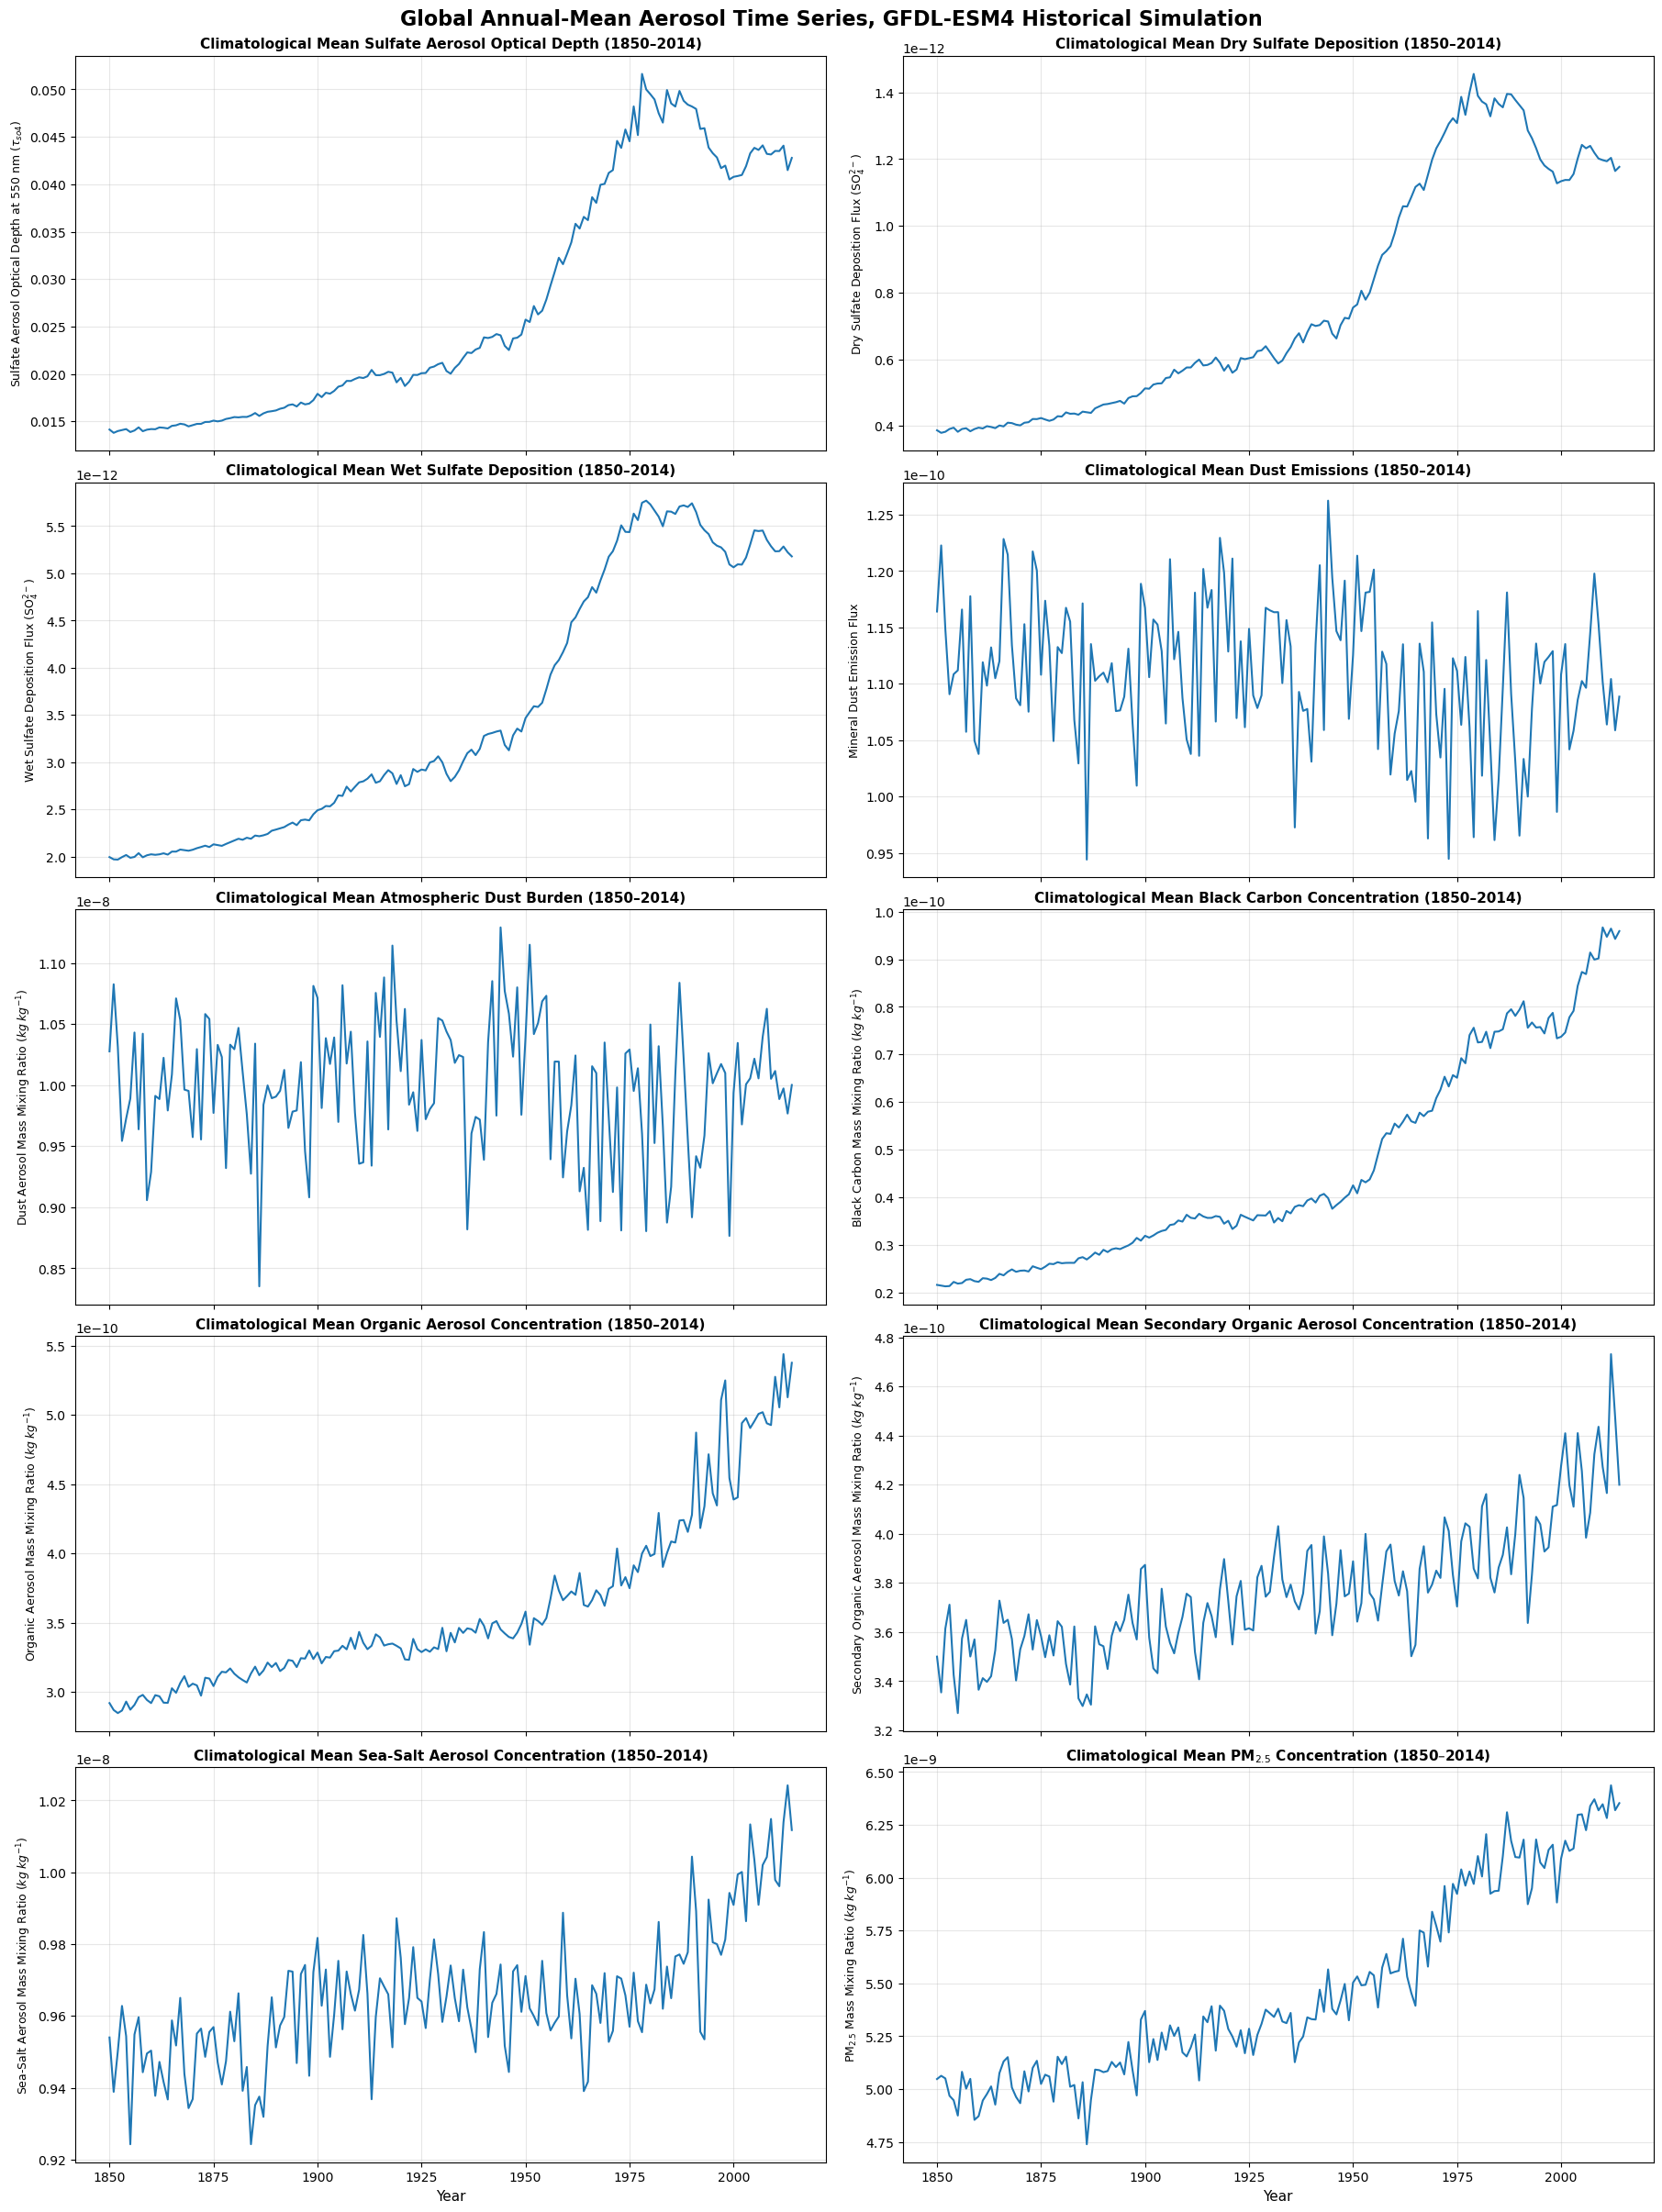

In [39]:
#plot_aerosol_climatology(ds, variable_id= "emidust")


plot_aerosol_timeseries(ds)

This function creates a large grid of 10 line graphs showing how different types of pollution and dust changed globally year by year from 1850 to 2014. For every aerosol variable, the code calculates a single worldwide average value for each year, plots that timeline on its own subplot slot, and adds clear labels and gridlines. It formats all the graphs cleanly side-by-side so you can easily compare historical trends across different atmospheric properties in a single glance.

In [49]:
def plot_aerosol_climatology(ds, output_filename="aerosol_climatology_panel.png"):
    """Plot 10 aerosol climatological-mean global maps in a 5x2 panel."""

    warnings.filterwarnings("ignore", category=UserWarning)

    variables = [
        "od550so4", "dryso4", "wetso4", "emidust", "mmrdust",
        "mmrbc", "mmroa", "mmrsoa", "mmrss", "mmrpm2p5"
    ]

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(22, 33),
        subplot_kw={"projection": ccrs.Robinson(central_longitude=0)}
    )

    axes = axes.flatten()

    for i, variable_id in enumerate(variables):
        ax = axes[i]

        mean_aod = ds[variable_id].mean(dim="time", skipna=True).compute()

        lon = mean_aod["lon"].values
        lat = mean_aod["lat"].values

        data_cyclic, lon_cyclic = cutil.add_cyclic_point(
            mean_aod.values,
            coord=lon
        )

        max_val = np.nanpercentile(data_cyclic, 99)
        levels = np.linspace(0, max_val, 11)

        contour = ax.contourf(
            lon_cyclic,
            lat,
            data_cyclic,
            levels=levels,
            transform=ccrs.PlateCarree(),
            cmap="YlOrRd",
            extend="max"
        )

        ax.set_global()
        ax.coastlines(resolution="110m", color="#333333", linewidth=0.6)

        cbar = fig.colorbar(
            contour,
            ax=ax,
            orientation="horizontal",
            pad=0.06,
            shrink=0.75,
            aspect=35
        )

        cbar.set_label(labels[variable_id], fontsize=10, labelpad=6)
        cbar.ax.tick_params(labelsize=8)
        cbar.outline.set_linewidth(0.5)

        ax.set_title(
            titles[variable_id],
            fontsize=11,
            pad=10
        )

    fig.suptitle(
        "Global Climatological Mean of Aerosols",
        fontsize=18,
        weight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    plt.savefig(output_filename, bbox_inches="tight", format="png", dpi=300)
    plt.show()

This function takes 164 years of historical climate data and compresses it into a single, high-resolution image containing a grid of 10 global maps. It loops through your different aerosol variables, calculates their long-term average over time, and neatly projects each onto a professional, curved world map with its own clear colorbar. Finally, it formats the layout with clean titles, stitches the panels together, and saves the entire matrix as a publication-ready picture.

In [42]:
def plot_annual_global_sum_od550so4(ds, output_filename="annual_global_sum_od550so4.png"):

    annual_global_sum = (
        ds["od550so4"]
        .sum(dim=("lat", "lon"), skipna=True)
        .groupby("time.year")
        .mean("time", skipna=True)
        .compute()
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        annual_global_sum["year"],
        annual_global_sum.values,
        linewidth=2,
    )

    ax.set_title(
        "Annual Global Sum of Sulfate Aerosol Optical Depth (1850–2014)",
        fontsize=14,
        weight="bold",
    )

    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(
        r"Annual Global Sum of Sulfate AOD ($\sum \tau_{so4}$)",
        fontsize=12,
    )

    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches="tight")
    plt.show()

    return annual_global_sum

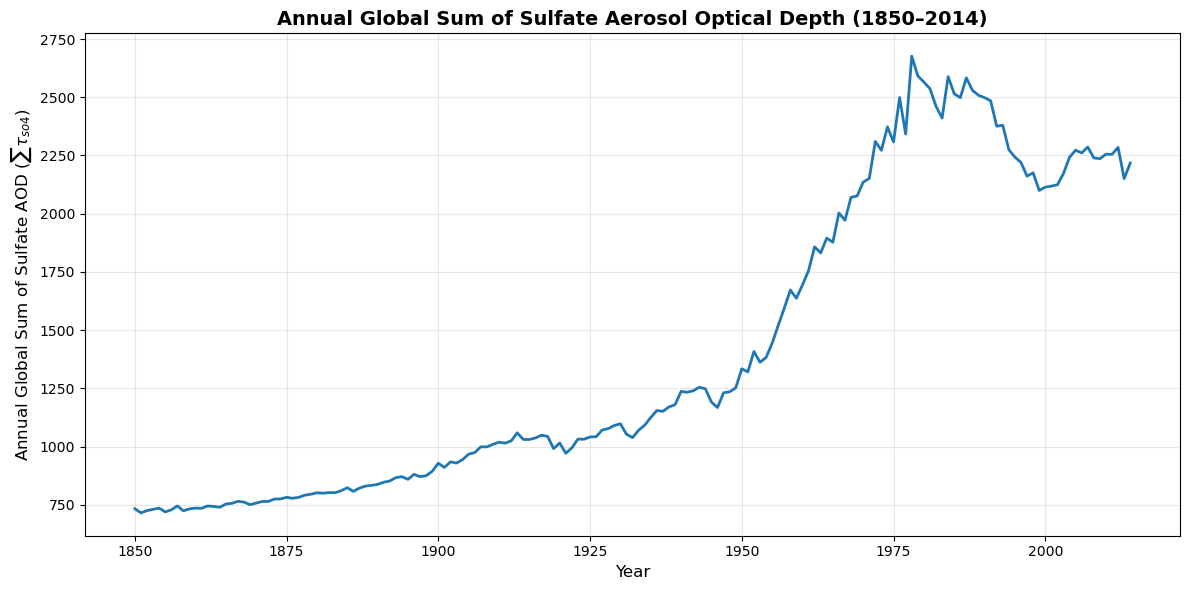

In [43]:
annual_global_sum = plot_annual_global_sum_od550so4(ds)

This function calculates the total amount of sulfate pollution around the entire globe for every single year and plots how that total changes over time on a line graph. It does this by adding up all the regional data points on the map (`.sum(dim=('lat', 'lon'))`), grouping them by calendar year, and saving the result as a clean, high-resolution trend line from 1850 to 2014. Finally, it returns the calculated annual values as a tidy list so you can use the numbers for further analysis.